In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV, cross_val_score, learning_curve
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report,ConfusionMatrixDisplay

In [3]:
data = pd.read_csv("donne.csv")

In [4]:
data.head()

,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,normal
1,30.807200,5.459076,76.199180,13.944380,10.0,normal
2,15.723226,3.000000,60.280820,13.243565,10.0,normal
3,57.796256,10.103074,104.990471,14.105683,10.0,normal
4,40.321320,7.110583,85.277902,14.641630,10.0,normal


In [5]:
data.shape

(5000, 6)

In [6]:
data.isnull().mean()*100

age_months          0.0
weight_kg           0.0
height_cm           0.0
muac_cm             0.0
bmi                 0.0
nutrition_status    0.0
dtype: float64

In [7]:
data["nutrition_status"].unique()

<ArrowStringArray>
['normal', 'moderate', 'severe']
Length: 3, dtype: str

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age_months        5000 non-null   float64
 1   weight_kg         5000 non-null   float64
 2   height_cm         5000 non-null   float64
 3   muac_cm           5000 non-null   float64
 4   bmi               5000 non-null   float64
 5   nutrition_status  5000 non-null   str    
dtypes: float64(5), str(1)
memory usage: 265.9 KB


In [9]:
feature = data.select_dtypes(include ="float")
cat_feature = data.select_dtypes(include = "object")

C:\Users\dc\AppData\Local\Temp\ipykernel_18644\3165787018.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_feature = data.select_dtypes(include = "object")


In [10]:
colonne = feature.columns.tolist()
colonne

['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi']

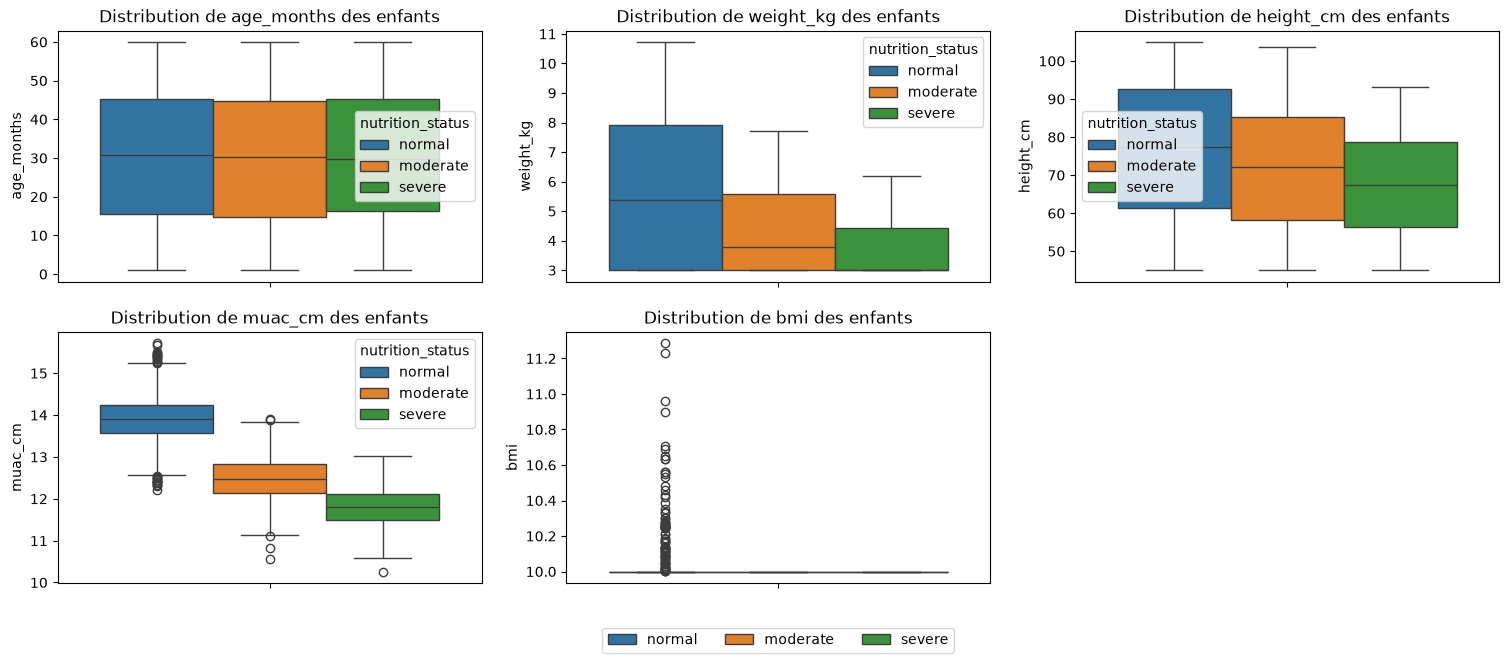

In [11]:
plt.figure(figsize= (18.6, 15))
for i in range(len(colonne)):
    plt.subplot(4, 3, i+1)
    plt.title(f"Distribution de {colonne[i]} des enfants")
    sns.boxplot(data = data, y = colonne[i], hue= "nutrition_status",)
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

In [12]:
encode = LabelEncoder()
for i in cat_feature:
    data[i] = encode.fit_transform(data[i])

In [13]:
data.head()

,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,1
1,30.807200,5.459076,76.199180,13.944380,10.0,1
2,15.723226,3.000000,60.280820,13.243565,10.0,1
3,57.796256,10.103074,104.990471,14.105683,10.0,1
4,40.321320,7.110583,85.277902,14.641630,10.0,1


<Axes: >

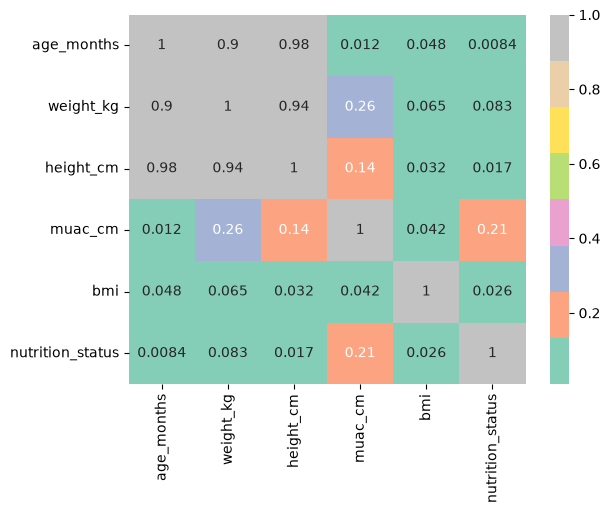

In [14]:
sns.heatmap(data.corr(numeric_only=True), annot = True, cmap ="Set2", alpha = 0.8)

In [15]:
X = data.drop(columns="nutrition_status")
y = data["nutrition_status"]

In [16]:
X

,age_months,weight_kg,height_cm,muac_cm,bmi
0,12.345052,3.000000,54.134002,13.160919,10.0
1,30.807200,5.459076,76.199180,13.944380,10.0
2,15.723226,3.000000,60.280820,13.243565,10.0
3,57.796256,10.103074,104.990471,14.105683,10.0
4,40.321320,7.110583,85.277902,14.641630,10.0
...,...,...,...,...,...
4995,36.397569,4.674426,79.668509,12.976748,10.0
4996,18.947724,3.371817,62.914947,13.806374,10.0
4997,37.636794,4.504413,77.793425,12.449221,10.0
4998,27.286957,4.799405,75.048627,14.152550,10.0


In [17]:
y

0       1
1       1
2       1
3       1
4       1
       ..
4995    0
4996    1
4997    0
4998    1
4999    2
Name: nutrition_status, Length: 5000, dtype: int64

In [18]:
#Decoupage du dataset 

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.2)

In [19]:
print(f"- Entrainement :{X_train.shape}\n- Evaluation {X_test.shape}")

- Entrainement :(4000, 5)
- Evaluation (1000, 5)


In [20]:
##Essayosn de standardiser les donnes pour avant d'entrainer notre modl KNN

scale  = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

 ### - 1 Modele KNN

In [21]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
model_knn.score(X_train, y_train)

0.9655

Le score sur les donnees d'entrainment est `96 %`

In [22]:
#Entrainment sur les donnes de validation

val_score = cross_val_score(KNeighborsClassifier(), X_train, y_train, cv = 5)

In [23]:
val_score

array([0.945  , 0.94875, 0.94625, 0.96125, 0.9475 ])

In [24]:
val_score = val_score.mean()
val_score  #Pa de overfitting ou under c'est miexu mais le model a perdui un peu de sa performace 

np.float64(0.9497500000000001)

In [25]:
rang = np.arange(1, 50)
train_score, val_score  = validation_curve(model_knn, X_train, y_train, param_name= "n_neighbors",param_range= rang, cv = 5 )

In [26]:
moy_train = train_score.mean(axis = 1)

In [27]:
moy_train

array([1.       , 0.9720625, 0.97075  , 0.9636875, 0.964    , 0.9595625,
       0.961    , 0.958625 , 0.9579375, 0.9546875, 0.9558125, 0.9545625,
       0.9546875, 0.952875 , 0.953125 , 0.95175  , 0.952375 , 0.95075  ,
       0.9495625, 0.947625 , 0.94725  , 0.9456875, 0.945375 , 0.9444375,
       0.9440625, 0.942625 , 0.9429375, 0.941375 , 0.9406875, 0.9395625,
       0.9396875, 0.9380625, 0.938125 , 0.9370625, 0.937    , 0.9355625,
       0.93575  , 0.935125 , 0.934625 , 0.9338125, 0.9335   , 0.9329375,
       0.93325  , 0.93175  , 0.932375 , 0.93075  , 0.9305   , 0.9291875,
       0.9293125])

In [28]:
moy_val = val_score.mean(axis = 1)
moy_val

array([0.94425, 0.94075, 0.94875, 0.947  , 0.94975, 0.94825, 0.94975,
       0.94825, 0.94825, 0.947  , 0.947  , 0.94575, 0.9465 , 0.94675,
       0.94375, 0.944  , 0.94425, 0.9435 , 0.9445 , 0.944  , 0.9435 ,
       0.94225, 0.94125, 0.94025, 0.94025, 0.93825, 0.938  , 0.9365 ,
       0.93575, 0.9345 , 0.934  , 0.93325, 0.93325, 0.9315 , 0.9315 ,
       0.9305 , 0.92975, 0.92875, 0.929  , 0.927  , 0.92675, 0.927  ,
       0.92675, 0.9255 , 0.92575, 0.92625, 0.92525, 0.925  , 0.92475])

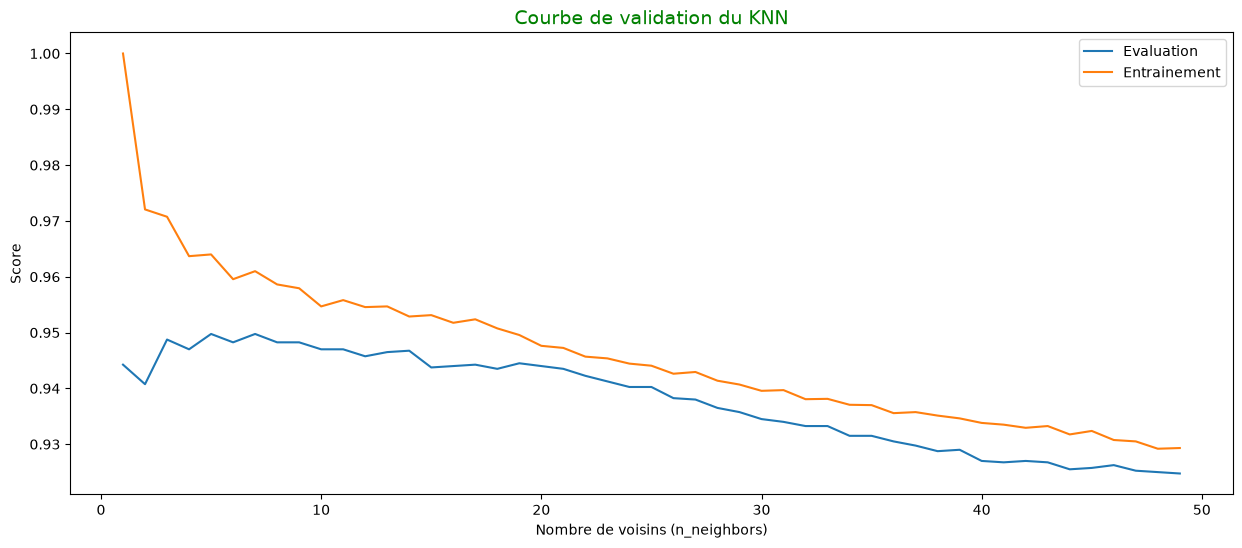

In [29]:
plt.figure(figsize= (15, 6))
plt.title("Courbe de validation du KNN", c = "green", size = 14)
plt.plot(rang, moy_val,  label = "Evaluation")
plt.plot(rang, moy_train,  label = "Entrainement")
plt.xlabel("Nombre de voisins (n_neighbors)")
plt.ylabel("Score")
plt.legend()

In [30]:
param_grid = {
    "n_neighbors" : [2,4,5,6],
    "weights" : ["uniform", "distance"],
    "metric" : ["manhattan", "ecludean", "minkowski"]
}

grid = GridSearchCV(
    estimator= model_knn,
    param_grid = param_grid,
    n_jobs = -1,
    scoring = "accuracy",
)

In [31]:
grid.fit(X_train, y_train)
grid.best_params_

C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
40 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Pyth

{'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}

In [32]:
grid.best_score_

np.float64(0.95075)

In [33]:
KNN_best = grid.best_estimator_

In [34]:
#Visipn des erreur de prediction du modele 

confusion_matrix(y_test, KNN_best.predict(X_test))

array([[179,   8,  11],
       [  9, 725,   0],
       [ 19,   0,  49]])

In [35]:
train_sizes, train_score, val_score = learning_curve(KNN_best, X_train, y_train, train_sizes=np.linspace(0.1, 1.0,100), cv = 5 )

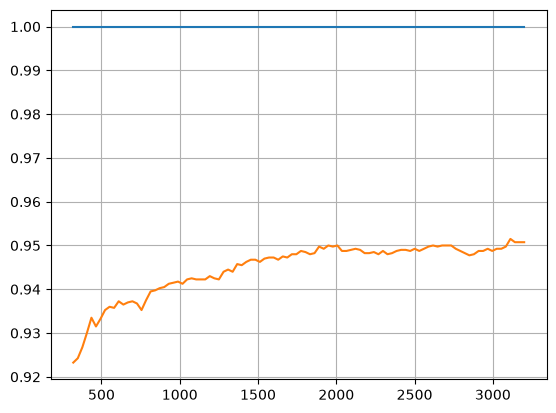

In [36]:
plt.plot(train_sizes, train_score.mean(axis = 1))
plt.plot(train_sizes, val_score.mean(axis = 1))
plt.grid()

In [37]:
y_pred = KNN_best.predict(X_test)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 Score  : {f1_score(y_test, y_pred, average = 'weighted'):.3f}")

Accuracy  : 0.953
F1 Score  : 0.953


In [52]:
metrique = classification_report(y_test, y_pred, output_dict = True)
pd.DataFrame(metrique).transpose().round(3)

,precision,recall,f1-score,support
0,0.865,0.904,0.884,198.000
1,0.989,0.988,0.988,734.000
2,0.817,0.721,0.766,68.000
accuracy,0.953,0.953,0.953,0.953
macro avg,0.890,0.871,0.879,1000.000
weighted avg,0.953,0.953,0.953,1000.000


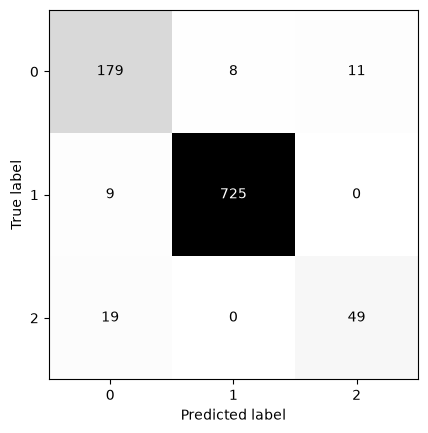

In [51]:
matrice = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=KNN_best.classes_)
matrice.plot(cmap = "Greys", colorbar = False)


## Model Decision Tree

In [54]:
model_ABR = DecisionTreeClassifier() #Initialisation du model de DecisionTreeClassifier

In [55]:
model_ABR.fit(X_train, y_train)
print(f"\nScore du model ABR sur les données d'entraînement : {model_ABR.score(X_train, y_train)}")


Score du model ABR sur les données d'entraînement : 1.0


In [57]:
val_score_ABR = cross_val_score(model_ABR, X_train, y_train, cv = 5)
print(f"\nScore de validation  ABR : {val_score_ABR}")
print(f"\nScore de validation croisée du model ABR : {val_score_ABR.mean()}")


Score de validation  ABR : [0.915   0.9125  0.90125 0.92    0.9125 ]

Score de validation croisée du model ABR : 0.91225


In [59]:
train_score , val_score = validation_curve(model_ABR, X_train, y_train, param_name= "max_depth",param_range= np.arange(1, 50), cv = 5 )

In [60]:
train_score.mean(axis = 1)

array([0.870375 , 0.8811875, 0.8911875, 0.902625 , 0.90825  , 0.927125 ,
       0.9354375, 0.944375 , 0.95275  , 0.9595   , 0.967    , 0.9729375,
       0.9795   , 0.984875 , 0.989375 , 0.9925625, 0.99525  , 0.9964375,
       0.9976875, 0.99875  , 0.9990625, 0.99925  , 0.9995   , 0.999625 ,
       0.99975  , 0.999875 , 0.9999375, 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       ])

In [61]:
val_score.mean(axis = 1)

array([0.86925, 0.8785 , 0.887  , 0.89325, 0.89725, 0.90975, 0.91   ,
       0.91275, 0.917  , 0.91175, 0.917  , 0.91475, 0.916  , 0.91475,
       0.916  , 0.916  , 0.91325, 0.91575, 0.9135 , 0.91275, 0.9135 ,
       0.9135 , 0.912  , 0.912  , 0.91275, 0.9135 , 0.91175, 0.91375,
       0.915  , 0.91175, 0.9125 , 0.91125, 0.9125 , 0.912  , 0.91525,
       0.91425, 0.911  , 0.91325, 0.912  , 0.913  , 0.913  , 0.91275,
       0.9155 , 0.91375, 0.915  , 0.9095 , 0.9135 , 0.913  , 0.91325])

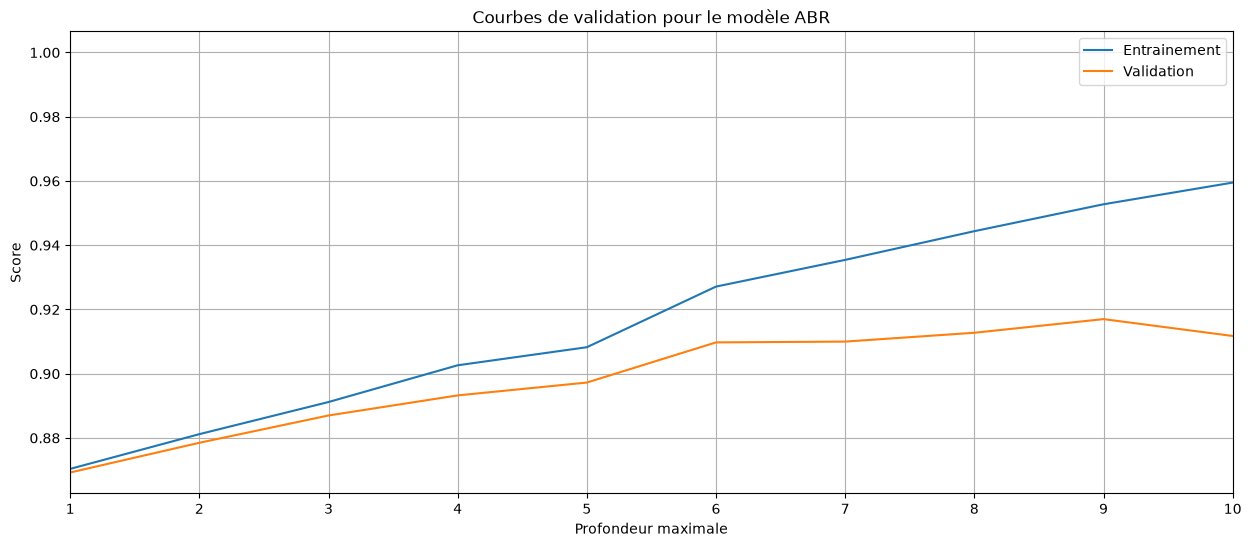

In [64]:
plt.figure(figsize= (15, 6))
plt.plot(np.arange(1, 50), train_score.mean(axis = 1), label = "Entrainement")
plt.plot(np.arange(1, 50), val_score.mean(axis = 1), label = "Validation")
plt.grid()
plt.xlabel("Profondeur maximale")
plt.ylabel("Score")
plt.title("Courbes de validation pour le modèle ABR")
plt.xlim(1, 10)
plt.legend()
plt.show()

- de ce que je vois graphiquement le model de ABR donne un meilleur score pour une profonduer maximum = 9, pour un score compris entre [0.90, 0.92]

In [ ]:
## Detemination du meilleeur estimateur 

param_grid = {
    estima
}